
# NutriTrack AI — Prediksi Level Obesitas
#  Capstone Project  Data Science Path
# Dataset: ObesityDataSet_raw_and_data_sinthetic.csv

Install & Import Library

In [ ]:
# !pip install pandas numpy matplotlib seaborn scikit-learn tensorflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Styling global
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 120

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


#BAGIAN 1 — Gathering Data

 Load Dataset

In [ ]:
df_raw = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic__1_.csv")

print(" Dataset berhasil dimuat!")
print(f"   Jumlah baris  : {df_raw.shape[0]}")
print(f"   Jumlah kolom  : {df_raw.shape[1]}")
print()
print("Preview 5 baris pertama:")
df_raw.head()

 Dataset berhasil dimuat!
   Jumlah baris  : 2111
   Jumlah kolom  : 17

Preview 5 baris pertama:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


#BAGIAN 2 — Assessing Data

Cek Tipe Data

In [ ]:
print("Tipe Data setiap kolom:")
print(df_raw.dtypes)

Tipe Data setiap kolom:
Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object


Cek Missing Values

In [ ]:
missing = df_raw.isnull().sum()
print("Missing Values per kolom:")
if missing.sum() == 0:
    print("Tidak ada missing values")
else:
    print(missing[missing > 0])

Missing Values per kolom:
Tidak ada missing values


Cek Duplikat

In [ ]:
dup_count = df_raw.duplicated().sum()
print(f"Jumlah baris duplikat: {dup_count}")

Jumlah baris duplikat: 24


Statistik Deskriptif

In [ ]:
print("Statistik Deskriptif (Fitur Numerik):")
df_raw.describe().round(2)

Statistik Deskriptif (Fitur Numerik):


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00
mean,24.31,1.70,86.59,2.42,2.69,2.01,1.01,0.66
std,6.35,0.09,26.19,0.53,0.78,0.61,0.85,0.61
min,14.00,1.45,39.00,1.00,1.00,1.00,0.00,0.00
25%,19.95,1.63,65.47,2.00,2.66,1.58,0.12,0.00
50%,22.78,1.70,83.00,2.39,3.00,2.00,1.00,0.63
75%,26.00,1.77,107.43,3.00,3.00,2.48,1.67,1.00
max,61.00,1.98,173.00,3.00,4.00,3.00,3.00,2.00


Nilai Unik Kolom Kategorikal

In [ ]:
cat_cols = ['Gender', 'family_history_with_overweight', 'FAVC',
            'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

print("Nilai unik kolom kategorikal:")
for col in cat_cols:
    print(f"   {col:35s}: {df_raw[col].unique().tolist()}")

Nilai unik kolom kategorikal:
   Gender                             : ['Female', 'Male']
   family_history_with_overweight     : ['yes', 'no']
   FAVC                               : ['no', 'yes']
   CAEC                               : ['Sometimes', 'Frequently', 'Always', 'no']
   SMOKE                              : ['no', 'yes']
   SCC                                : ['no', 'yes']
   CALC                               : ['no', 'Sometimes', 'Frequently', 'Always']
   MTRANS                             : ['Public_Transportation', 'Walking', 'Automobile', 'Motorbike', 'Bike']


Distribusi Target

In [ ]:
print("Distribusi Kelas Target (NObeyesdad):")
print(df_raw['NObeyesdad'].value_counts())

Distribusi Kelas Target (NObeyesdad):
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


#BAGIAN 3 — Cleaning Data

Hapus Duplikat & Reset Index

In [ ]:
df = df_raw.copy()

sebelum = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
sesudah = len(df)

print(f" Duplikat dihapus: {sebelum - sesudah} baris")
print(f"   Sisa data: {sesudah} baris")

 Duplikat dihapus: 24 baris
   Sisa data: 2087 baris


Rename Kolom

In [ ]:
rename_map = {
    'family_history_with_overweight': 'family_history',
    'FAVC'  : 'frequent_high_cal_food',
    'FCVC'  : 'vegetable_freq',
    'NCP'   : 'meals_per_day',
    'CAEC'  : 'snack_between_meals',
    'SMOKE' : 'smoking',
    'CH2O'  : 'water_daily',
    'SCC'   : 'calories_monitoring',
    'FAF'   : 'physical_activity_freq',
    'TUE'   : 'tech_usage_hours',
    'CALC'  : 'alcohol_consumption',
    'MTRANS': 'transportation',
    'NObeyesdad': 'obesity_level'
}
df.rename(columns=rename_map, inplace=True)
print(" Kolom berhasil di-rename")
print(f"   Kolom baru: {df.columns.tolist()}")

 Kolom berhasil di-rename
   Kolom baru: ['Gender', 'Age', 'Height', 'Weight', 'family_history', 'frequent_high_cal_food', 'vegetable_freq', 'meals_per_day', 'snack_between_meals', 'smoking', 'water_daily', 'calories_monitoring', 'physical_activity_freq', 'tech_usage_hours', 'alcohol_consumption', 'transportation', 'obesity_level']


Encoding Kolom Biner (yes/no → 1/0)

In [ ]:
binary_cols = ['family_history', 'frequent_high_cal_food',
               'smoking', 'calories_monitoring']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

print(f" Binary encoding selesai untuk: {binary_cols}")

 Binary encoding selesai untuk: ['family_history', 'frequent_high_cal_food', 'smoking', 'calories_monitoring']


Encoding Kolom Ordinal

In [ ]:
ordinal_map = {
    'snack_between_meals': {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3},
    'alcohol_consumption' : {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3},
}

for col, mapping in ordinal_map.items():
    df[col] = df[col].map(mapping)

print(f"  Ordinal encoding selesai untuk: {list(ordinal_map.keys())}")
print("   Skala: no=0, Sometimes=1, Frequently=2, Always=3")

  Ordinal encoding selesai untuk: ['snack_between_meals', 'alcohol_consumption']
   Skala: no=0, Sometimes=1, Frequently=2, Always=3


Encoding Kolom Nominal (Label Encoding)

In [ ]:
nominal_cols = ['Gender', 'transportation']
le = LabelEncoder()

for col in nominal_cols:
    df[col] = le.fit_transform(df[col])

print(f" Label Encoding selesai untuk: {nominal_cols}")
print(f"   Gender      : Female=0, Male=1")
print(f"   Transportation: {dict(zip(le.classes_, le.transform(le.classes_)))}")

 Label Encoding selesai untuk: ['Gender', 'transportation']
   Gender      : Female=0, Male=1
   Transportation: {'Automobile': np.int64(0), 'Bike': np.int64(1), 'Motorbike': np.int64(2), 'Public_Transportation': np.int64(3), 'Walking': np.int64(4)}


Encoding Target (Label → Angka)

In [ ]:
target_order = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]
target_map = {label: idx for idx, label in enumerate(target_order)}
df['obesity_level_encoded'] = df['obesity_level'].map(target_map)

print("  Target encoding selesai")
print(f"   Mapping: {target_map}")

  Target encoding selesai
   Mapping: {'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Overweight_Level_I': 2, 'Overweight_Level_II': 3, 'Obesity_Type_I': 4, 'Obesity_Type_II': 5, 'Obesity_Type_III': 6}


Scaling Fitur Numerik (MinMaxScaler)

In [ ]:
num_cols = ['Age', 'Height', 'Weight', 'vegetable_freq',
            'meals_per_day', 'water_daily',
            'physical_activity_freq', 'tech_usage_hours']

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

print(f"   MinMax Scaling selesai untuk {len(num_cols)} fitur numerik")
print(f"   Semua nilai sekarang berada di rentang [0, 1]")

# Preview hasil akhir
print("\nDataset setelah cleaning (5 baris pertama):")
df.head()


   MinMax Scaling selesai untuk 8 fitur numerik
   Semua nilai sekarang berada di rentang [0, 1]

Dataset setelah cleaning (5 baris pertama):


,Gender,Age,Height,Weight,family_history,frequent_high_cal_food,vegetable_freq,meals_per_day,snack_between_meals,smoking,water_daily,calories_monitoring,physical_activity_freq,tech_usage_hours,alcohol_consumption,transportation,obesity_level,obesity_level_encoded
0,0,0.148936,0.320755,0.186567,1,0,0.5,0.666667,1,0,0.5,0,0.000000,0.5,0,3,Normal_Weight,1
1,0,0.148936,0.132075,0.126866,1,0,1.0,0.666667,1,1,1.0,1,1.000000,0.0,1,3,Normal_Weight,1
2,1,0.191489,0.660377,0.283582,1,0,0.5,0.666667,1,0,0.5,0,0.666667,0.5,2,3,Normal_Weight,1
3,1,0.276596,0.660377,0.358209,0,0,1.0,0.666667,1,0,0.5,0,0.666667,0.0,2,4,Overweight_Level_I,2
4,1,0.170213,0.622642,0.379104,0,0,0.5,0.000000,1,0,0.5,0,0.000000,0.0,1,3,Overweight_Level_II,3


#BAGIAN 4 — Data Dictionary

Tampilkan Data Dictionary

In [ ]:
data_dict = pd.DataFrame({
    'Fitur': [
        'Gender', 'Age', 'Height', 'Weight',
        'family_history', 'frequent_high_cal_food', 'vegetable_freq',
        'meals_per_day', 'snack_between_meals', 'smoking',
        'water_daily', 'calories_monitoring', 'physical_activity_freq',
        'tech_usage_hours', 'alcohol_consumption', 'transportation',
        'obesity_level'
    ],
    'Tipe': [
        'Kategorikal', 'Numerik', 'Numerik', 'Numerik',
        'Biner', 'Biner', 'Numerik',
        'Numerik', 'Ordinal', 'Biner',
        'Numerik', 'Biner', 'Numerik',
        'Numerik', 'Ordinal', 'Kategorikal',
        'Target'
    ],
    'Keterangan': [
        'Jenis kelamin (0=Female, 1=Male)',
        'Usia responden (tahun), sudah di-scale',
        'Tinggi badan (meter), sudah di-scale',
        'Berat badan (kg), sudah di-scale',
        'Riwayat keluarga overweight (0=Tidak, 1=Ya)',
        'Konsumsi makanan tinggi kalori (0=Tidak, 1=Ya)',
        'Frekuensi konsumsi sayuran (scale 0–1)',
        'Jumlah makan utama per hari (scale 0–1)',
        'Kebiasaan ngemil (0=Tidak, 1=Kadang, 2=Sering, 3=Selalu)',
        'Kebiasaan merokok (0=Tidak, 1=Ya)',
        'Konsumsi air harian (liter), sudah di-scale',
        'Pemantauan kalori harian (0=Tidak, 1=Ya)',
        'Frekuensi aktivitas fisik/minggu (scale 0–1)',
        'Waktu pakai teknologi per hari (scale 0–1)',
        'Konsumsi alkohol (0=Tidak, 1=Kadang, 2=Sering, 3=Selalu)',
        'Moda transportasi utama (Label Encoded)',
        'Level obesitas — TARGET PREDIKSI (7 kelas, encoded 0–6)'
    ]
})

print("   DATA DICTIONARY")
print("=" * 80)
data_dict

   DATA DICTIONARY


,Fitur,Tipe,Keterangan
0,Gender,Kategorikal,"Jenis kelamin (0=Female, 1=Male)"
1,Age,Numerik,"Usia responden (tahun), sudah di-scale"
2,Height,Numerik,"Tinggi badan (meter), sudah di-scale"
3,Weight,Numerik,"Berat badan (kg), sudah di-scale"
4,family_history,Biner,"Riwayat keluarga overweight (0=Tidak, 1=Ya)"
5,frequent_high_cal_food,Biner,"Konsumsi makanan tinggi kalori (0=Tidak, 1=Ya)"
6,vegetable_freq,Numerik,Frekuensi konsumsi sayuran (scale 0–1)
7,meals_per_day,Numerik,Jumlah makan utama per hari (scale 0–1)
8,snack_between_meals,Ordinal,"Kebiasaan ngemil (0=Tidak, 1=Kadang, 2=Sering,..."
9,smoking,Biner,"Kebiasaan merokok (0=Tidak, 1=Ya)"


#BAGIAN 5 — EDA & Visualisasi

Plot 1: Distribusi Kelas Obesitas

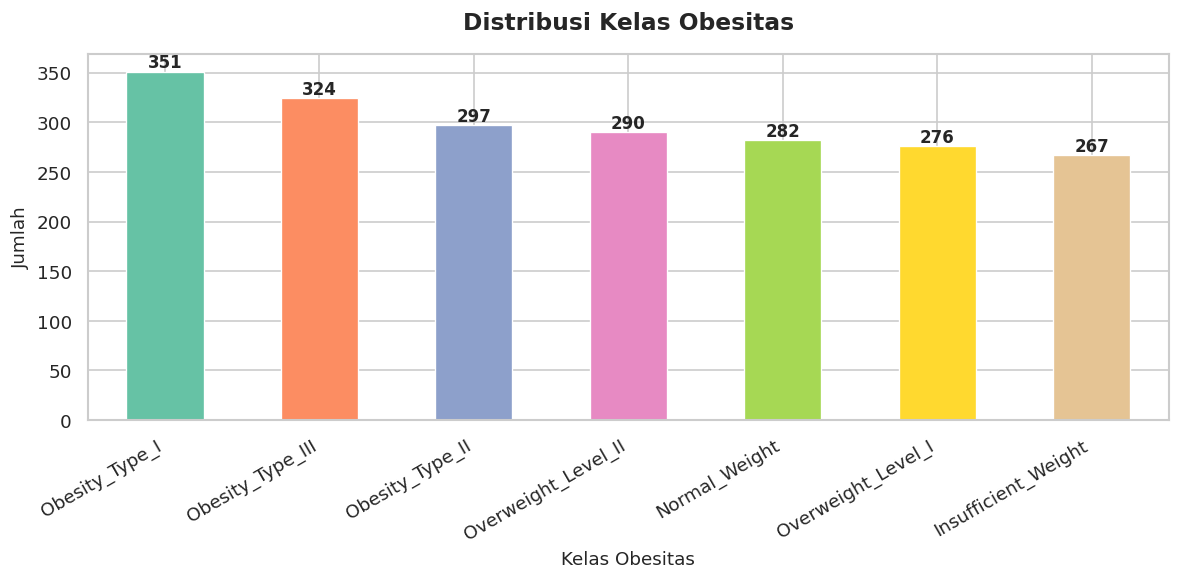

   Insight: Distribusi kelas cukup seimbang (272–351 per kelas).
   Dataset menggunakan data sintetis untuk menjaga keseimbangan kelas.


In [ ]:
# Pertanyaan Bisnis 1:
# "Bagaimana distribusi level obesitas di populasi dataset ini?"

fig, ax = plt.subplots(figsize=(10, 5))
order = df['obesity_level'].value_counts().index
colors = sns.color_palette("Set2", len(order))

df['obesity_level'].value_counts()[order].plot(
    kind='bar', ax=ax, color=colors, edgecolor='white', linewidth=0.8
)
ax.set_title('Distribusi Kelas Obesitas', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Kelas Obesitas', fontsize=11)
ax.set_ylabel('Jumlah', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('plot1_distribusi_target.png')
plt.show()

# Insight
print("   Insight: Distribusi kelas cukup seimbang (272–351 per kelas).")
print("   Dataset menggunakan data sintetis untuk menjaga keseimbangan kelas.")

Plot 2: Distribusi Usia & BMI

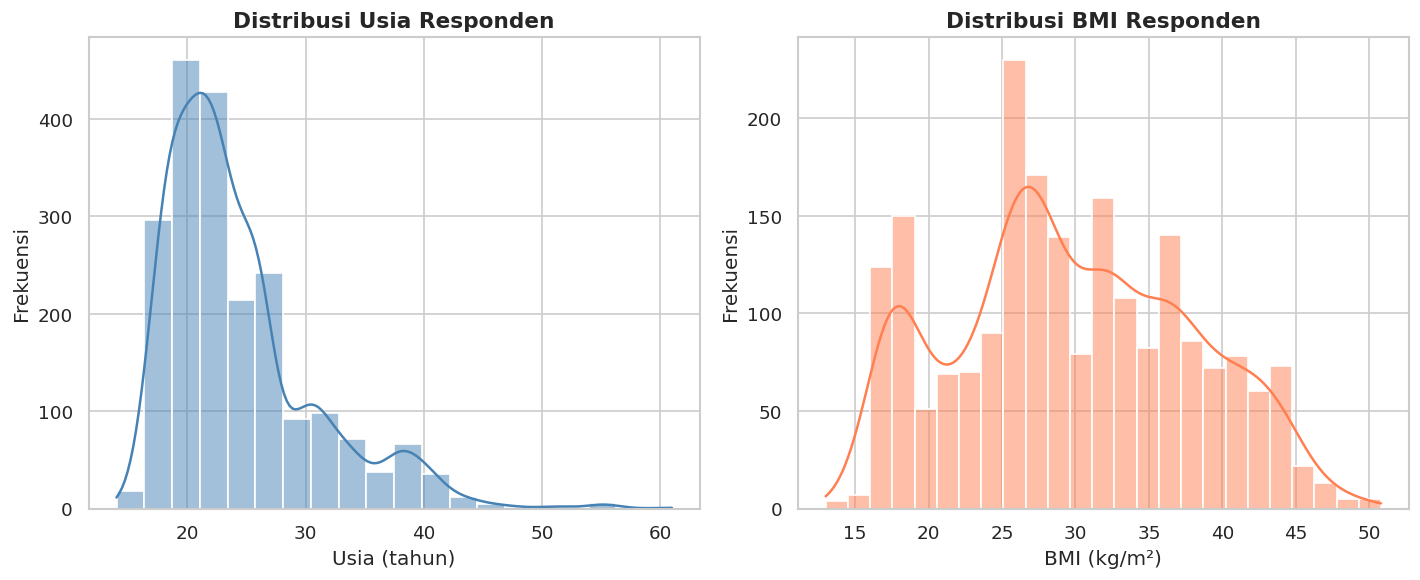

    Insight: Mayoritas responden berusia 18–30 tahun.
   BMI rata-rata: 29.8 kg/m²


In [ ]:
# Pertanyaan Bisnis 2:
# "Bagaimana profil usia dan BMI responden?"

df_raw_clean = df_raw.drop_duplicates().copy()
df_raw_clean['BMI'] = df_raw_clean['Weight'] / (df_raw_clean['Height'] ** 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_raw_clean['Age'], bins=20, kde=True,
             ax=axes[0], color='steelblue')
axes[0].set_title('Distribusi Usia Responden', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Usia (tahun)')
axes[0].set_ylabel('Frekuensi')

sns.histplot(df_raw_clean['BMI'], bins=25, kde=True,
             ax=axes[1], color='coral')
axes[1].set_title('Distribusi BMI Responden', fontsize=13, fontweight='bold')
axes[1].set_xlabel('BMI (kg/m²)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('plot2_distribusi_usia_bmi.png')
plt.show()

print("    Insight: Mayoritas responden berusia 18–30 tahun.")
print(f"   BMI rata-rata: {df_raw_clean['BMI'].mean():.1f} kg/m²")

Plot 3: BMI per Kelas Obesitas

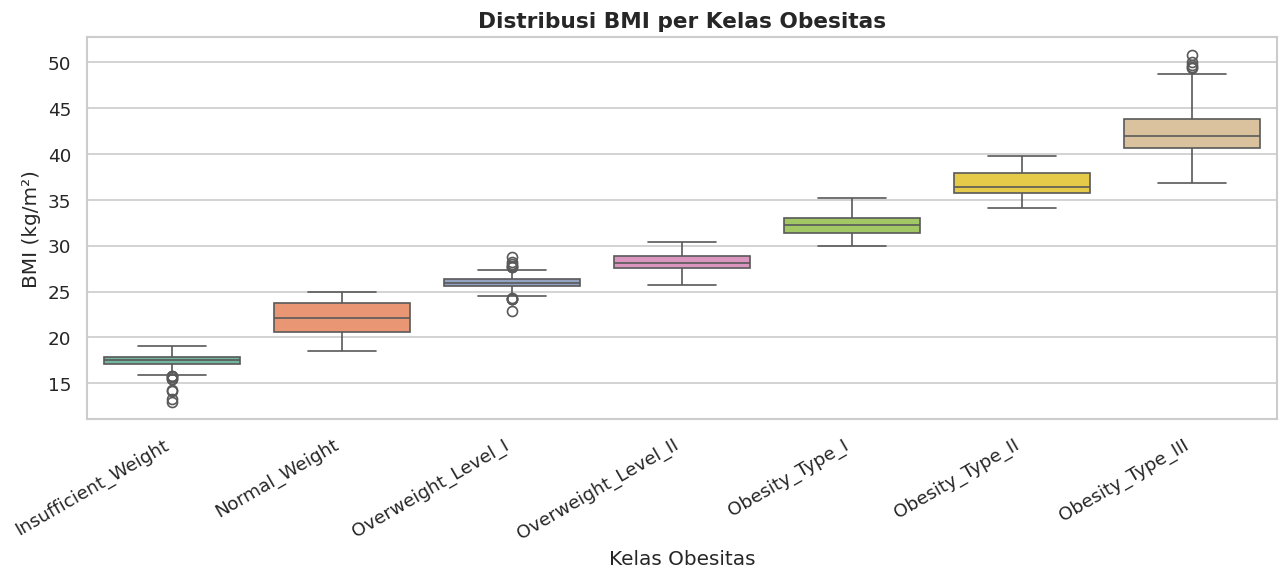

   Insight: BMI meningkat secara konsisten dari Insufficient_Weight
   ke Obesity_Type_III, menunjukkan korelasi kuat antara BMI dan kelas.


In [ ]:
# Pertanyaan Bisnis 3:
# "Apakah ada perbedaan BMI yang signifikan antar kelas obesitas?"

order_bmi = [
    'Insufficient_Weight', 'Normal_Weight',
    'Overweight_Level_I', 'Overweight_Level_II',
    'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
]

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df_raw_clean, x='NObeyesdad', y='BMI',
            order=order_bmi, palette='Set2', ax=ax)
ax.set_title('Distribusi BMI per Kelas Obesitas', fontsize=13, fontweight='bold')
ax.set_xlabel('Kelas Obesitas')
ax.set_ylabel('BMI (kg/m²)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('plot3_bmi_per_kelas.png')
plt.show()

print("   Insight: BMI meningkat secara konsisten dari Insufficient_Weight")
print("   ke Obesity_Type_III, menunjukkan korelasi kuat antara BMI dan kelas.")

Plot 4: Correlation Heatmap

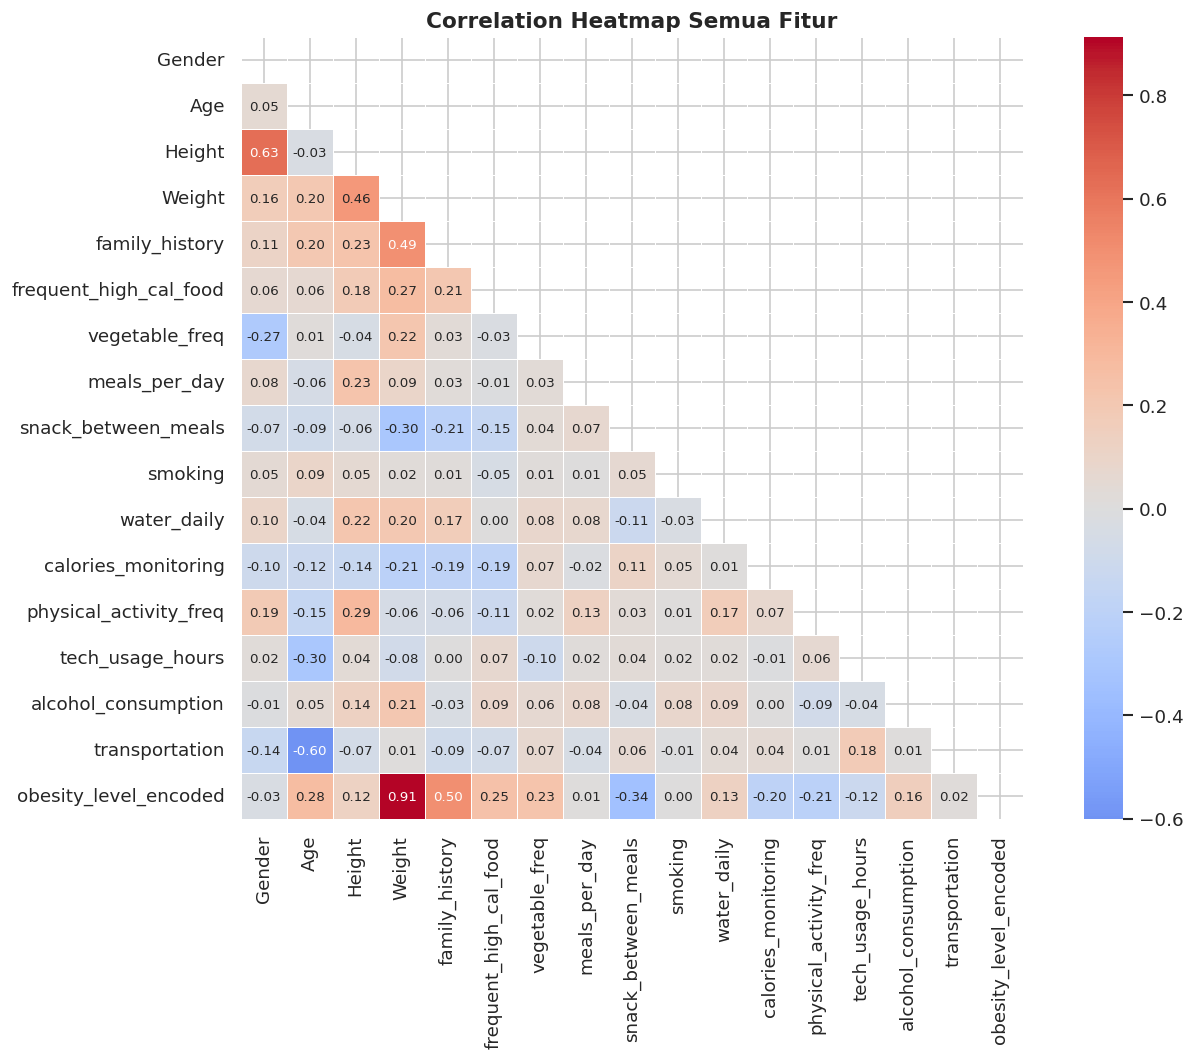

 Insight: Weight & Height memiliki korelasi tertinggi dengan obesity_level_encoded.


In [ ]:
# Pertanyaan Bisnis 4:
# "Faktor apa yang paling berkorelasi dengan level obesitas?"

fig, ax = plt.subplots(figsize=(12, 9))
corr_df = df.drop(columns=['obesity_level']).copy()
corr = corr_df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            annot_kws={'size': 8}, linewidths=0.5, square=True)
ax.set_title('Correlation Heatmap Semua Fitur', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('plot4_correlation_heatmap.png')
plt.show()

print(" Insight: Weight & Height memiliki korelasi tertinggi dengan obesity_level_encoded.")

Plot 5: Aktivitas Fisik per Kelas

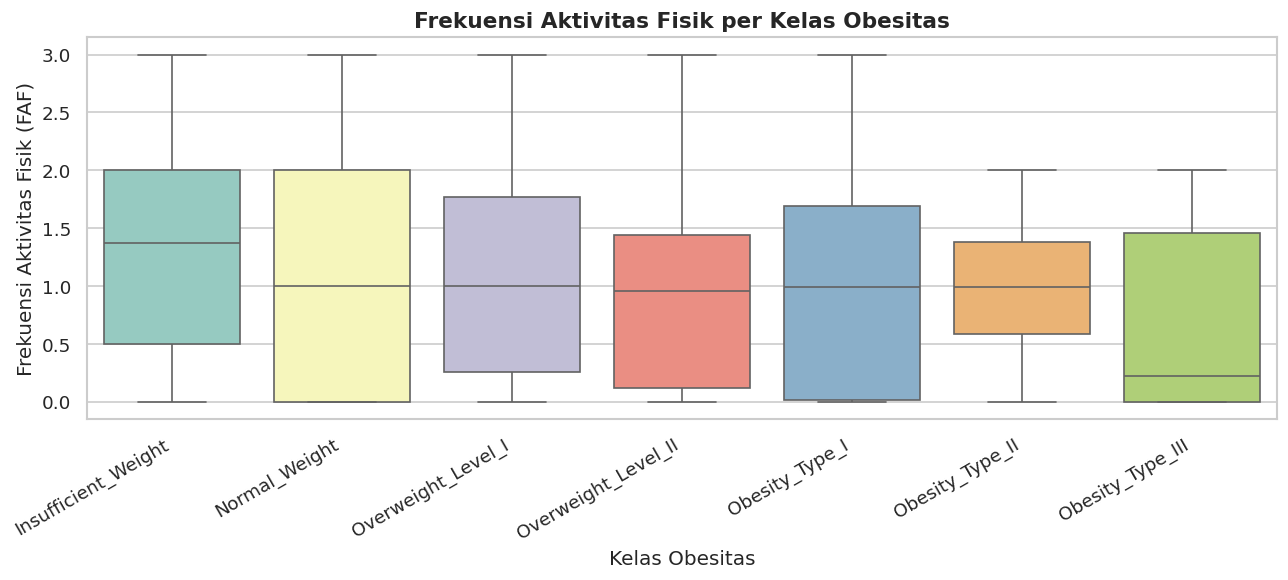

   Insight: Kelas obesitas tinggi (Type II & III) cenderung memiliki
   aktivitas fisik lebih rendah dibanding Normal Weight.


In [ ]:
# Pertanyaan Bisnis 5:
# "Apakah orang yang aktif olahraga cenderung tidak obesitas?"

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df_raw_clean, x='NObeyesdad', y='FAF',
            order=order_bmi, palette='Set3', ax=ax)
ax.set_title('Frekuensi Aktivitas Fisik per Kelas Obesitas',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Kelas Obesitas')
ax.set_ylabel('Frekuensi Aktivitas Fisik (FAF)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('plot5_aktivitas_per_kelas.png')
plt.show()

print("   Insight: Kelas obesitas tinggi (Type II & III) cenderung memiliki")
print("   aktivitas fisik lebih rendah dibanding Normal Weight.")

Plot 6: Riwayat Keluarga per Kelas

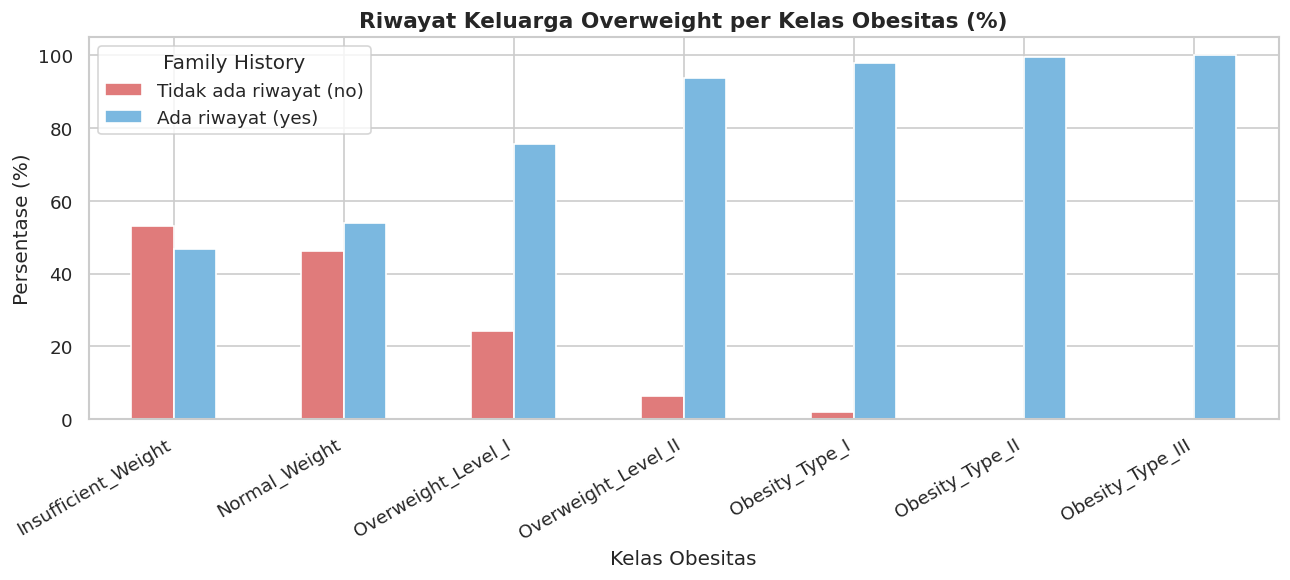

   Insight: Mayoritas Obesity_Type_III memiliki riwayat keluarga overweight.
   Riwayat keluarga adalah faktor risiko signifikan.


In [ ]:
# Pertanyaan Bisnis 6:
# "Apakah riwayat keluarga meningkatkan risiko obesitas?"

fig, ax = plt.subplots(figsize=(11, 5))
cross = pd.crosstab(
    df_raw_clean['NObeyesdad'],
    df_raw_clean['family_history_with_overweight'],
    normalize='index'
) * 100
cross = cross.reindex(order_bmi)
cross.plot(kind='bar', ax=ax,
           color=['#e07b7b', '#7bb8e0'], edgecolor='white')

ax.set_title('Riwayat Keluarga Overweight per Kelas Obesitas (%)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Kelas Obesitas')
ax.set_ylabel('Persentase (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(['Tidak ada riwayat (no)', 'Ada riwayat (yes)'],
          title='Family History')

plt.tight_layout()
plt.savefig('plot6_riwayat_keluarga.png')
plt.show()

print("   Insight: Mayoritas Obesity_Type_III memiliki riwayat keluarga overweight.")
print("   Riwayat keluarga adalah faktor risiko signifikan.")

#BAGIAN 6 — Train / Validation / Test Split

Split Data 70 / 15 / 15

In [ ]:
feature_cols = [col for col in df.columns
                if col not in ['obesity_level', 'obesity_level_encoded']]

X = df[feature_cols].values
y = df['obesity_level_encoded'].values

# Split pertama: 70% train, 30% sementara
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Split kedua: 30% sementara → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("   Split data selesai!")
print(f"   Train : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Val   : {X_val.shape[0]} baris  ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"   Test  : {X_test.shape[0]} baris  ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\n   Jumlah fitur input : {X_train.shape[1]}")
print(f"   Jumlah kelas target: {len(np.unique(y))}")

   Split data selesai!
   Train : 1460 baris (70.0%)
   Val   : 313 baris  (15.0%)
   Test  : 314 baris  (15.0%)

   Jumlah fitur input : 16
   Jumlah kelas target: 7


Simpan Data Split & Dataset Bersih

In [ ]:
np.save('X_train.npy', X_train)
np.save('X_val.npy',   X_val)
np.save('X_test.npy',  X_test)
np.save('y_train.npy', y_train)
np.save('y_val.npy',   y_val)
np.save('y_test.npy',  y_test)

df.to_csv('dataset_cleaned.csv', index=False)

print("   File tersimpan:")
print("   X_train.npy, X_val.npy, X_test.npy")
print("   y_train.npy, y_val.npy, y_test.npy")
print("   dataset_cleaned.csv")
print()
print("=" * 60)

   File tersimpan:
   X_train.npy, X_val.npy, X_test.npy
   y_train.npy, y_val.npy, y_test.npy
   dataset_cleaned.csv



#BAGIAN 7 — Build Model (TensorFlow Functional API)

Import TensorFlow

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

print(f"TensorFlow versi: {tf.__version__}")

TensorFlow versi: 2.20.0


Load Data Split

In [ ]:
import numpy as np

X_train = np.load('X_train.npy')
X_val   = np.load('X_val.npy')
X_test  = np.load('X_test.npy')
y_train = np.load('y_train.npy')
y_val   = np.load('y_val.npy')
y_test  = np.load('y_test.npy')

NUM_FEATURES = X_train.shape[1]  # 16
NUM_CLASSES  = 7

print(f"   Data berhasil dimuat!")
print(f"   X_train shape : {X_train.shape}")
print(f"   X_val shape   : {X_val.shape}")
print(f"   X_test shape  : {X_test.shape}")
print(f"   Jumlah fitur  : {NUM_FEATURES}")
print(f"   Jumlah kelas  : {NUM_CLASSES}")

   Data berhasil dimuat!
   X_train shape : (1460, 16)
   X_val shape   : (313, 16)
   X_test shape  : (314, 16)
   Jumlah fitur  : 16
   Jumlah kelas  : 7


Bangun Arsitektur Model (Functional API)

In [ ]:
def build_nutritrack_model(num_features, num_classes):
    # --- INPUT ---
    inputs = keras.Input(shape=(num_features,), name='input_layer')

    # --- BLOCK 1 ---
    x = layers.Dense(128, activation='relu', name='dense_1')(inputs)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(0.3, name='dropout_1')(x)

    # --- BLOCK 2 ---
    x = layers.Dense(64, activation='relu', name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Dropout(0.3, name='dropout_2')(x)

    # --- BLOCK 3 ---
    # Tempat AttentionLayer akan disisipkan (Step 2b)
    x = layers.Dense(64, activation='relu', name='dense_3')(x)

    # --- BLOCK 4 ---
    x = layers.Dense(32, activation='relu', name='dense_4')(x)

    # --- OUTPUT ---
    outputs = layers.Dense(num_classes, activation='softmax', name='output_layer')(x)

    # Bungkus jadi Model
    model = Model(inputs=inputs, outputs=outputs, name='NutriTrack_Model')
    return model


model = build_nutritrack_model(NUM_FEATURES, NUM_CLASSES)
print("Model berhasil dibangun!")

Model berhasil dibangun!


Tampilkan Ringkasan Model

In [ ]:
model.summary()

Model: "NutriTrack_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,671 (69.03 KB)

 Trainable params: 17,287 (67.53 KB)

 Non-trainable params: 384 (1.50 KB)

Visualisasi Arsitektur Model

In [ ]:
# Visualisasi struktur model sebagai diagram
try:
    tf.keras.utils.plot_model(
        model,
        to_file='model_architecture.png',
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',        # Top to Bottom
        dpi=120
    )
    print("  Diagram model disimpan: model_architecture.png")

    from IPython.display import Image
    Image('model_architecture.png')

except Exception as e:
    print(f"    plot_model tidak tersedia: {e}")
    print("   Lanjut ke cell berikutnya, tidak masalah.")

  Diagram model disimpan: model_architecture.png


Hitung Total Parameter

In [ ]:
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])

print(f"   Statistik Model:")
print(f"   Total parameter        : {total_params:,}")
print(f"   Trainable parameter    : {trainable_params:,}")
print(f"   Non-trainable parameter: {total_params - trainable_params:,}")
print()
print("   Arsitektur siap!")

   Statistik Model:
   Total parameter        : 17,671
   Trainable parameter    : 17,287
   Non-trainable parameter: 384

   Arsitektur siap!


#BAGIAN 8 — Custom Layer (Attention Layer)

Definisi Custom Attention Layer

In [ ]:
# AttentionLayer bekerja dengan cara:
# 1. Terima input fitur (shape: batch, 64)
# 2. Hitung skor kepentingan tiap fitur pakai Dense + Softmax
# 3. Kalikan skor dengan input → fitur penting diperkuat

class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        # Layer Dense internal untuk hitung skor
        # units = jumlah fitur input
        self.attention_dense = layers.Dense(
            units=input_shape[-1],
            activation='softmax',
            name='attention_scores'
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        # Hitung skor kepentingan tiap fitur
        attention_scores = self.attention_dense(inputs)

        # Kalikan skor dengan input asli
        # Fitur dengan skor tinggi → nilainya diperkuat
        weighted_output = inputs * attention_scores

        return weighted_output

    def get_config(self):
        # Wajib ada agar model bisa disimpan & dimuat ulang
        config = super(AttentionLayer, self).get_config()
        return config


print("  AttentionLayer berhasil didefinisikan!")

  AttentionLayer berhasil didefinisikan!


Test Attention Layer (sebelum dipakai di model)

In [ ]:
# Coba layer ini dengan data dummy dulu
# untuk memastikan shape input/output sudah benar

dummy_input = tf.random.normal(shape=(4, 64))  # 4 sampel, 64 fitur
attention_test = AttentionLayer(name='test_attention')
dummy_output = attention_test(dummy_input)

print("   Test AttentionLayer:")
print(f"   Input shape  : {dummy_input.shape}")
print(f"   Output shape : {dummy_output.shape}")
print(f"   Shape sama   : {dummy_input.shape == dummy_output.shape} ")
print()

# Lihat contoh skor attention
scores = attention_test.attention_dense(dummy_input)
print(f"   Contoh attention scores (sampel pertama):")
print(f"   Min skor : {scores[0].numpy().min():.4f}")
print(f"   Max skor : {scores[0].numpy().max():.4f}")
print(f"   Sum skor : {scores[0].numpy().sum():.4f} (harusnya ≈ 1.0 karena Softmax)")

   Test AttentionLayer:
   Input shape  : (4, 64)
   Output shape : (4, 64)
   Shape sama   : True 

   Contoh attention scores (sampel pertama):
   Min skor : 0.0010
   Max skor : 0.1031
   Sum skor : 1.0000 (harusnya ≈ 1.0 karena Softmax)


Rebuild Model dengan Attention Layer

In [ ]:
# Sekarang kita update fungsi build_model dari Step 2a
# dengan menyisipkan AttentionLayer di Block 3

def build_nutritrack_model_v2(num_features, num_classes):
    # --- INPUT ---
    inputs = keras.Input(shape=(num_features,), name='input_layer')

    # --- BLOCK 1 ---
    x = layers.Dense(128, activation='relu', name='dense_1')(inputs)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(0.3, name='dropout_1')(x)

    # --- BLOCK 2 ---
    x = layers.Dense(64, activation='relu', name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Dropout(0.3, name='dropout_2')(x)

    # --- BLOCK 3 — Custom Attention Layer disisipkan di sini ---
    x = layers.Dense(64, activation='relu', name='dense_3')(x)
    x = AttentionLayer(name='attention_layer')(x)   #  CUSTOM LAYER

    # --- BLOCK 4 ---
    x = layers.Dense(32, activation='relu', name='dense_4')(x)

    # --- OUTPUT ---
    outputs = layers.Dense(
        num_classes, activation='softmax', name='output_layer'
    )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name='NutriTrack_Model_v2'
    )
    return model

    # Buat ulang model dengan attention
model = build_nutritrack_model_v2(NUM_FEATURES, NUM_CLASSES)
print("Model v2 dengan AttentionLayer berhasil dibangun!")


Model v2 dengan AttentionLayer berhasil dibangun!


Tampilkan Summary Model v2


In [ ]:
model.summary()

# Konfirmasi attention layer ada di model
layer_names = [l.name for l in model.layers]
print()
if 'attention_layer' in layer_names:
    print("AttentionLayer terkonfirmasi ada di model!")
else:
    print("AttentionLayer tidak ditemukan, cek kembali.")

Model: "NutriTrack_Model_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 64)             │         4,160 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,831 (85.28 KB)

 Trainable params: 21,447 (83.78 KB)

 Non-trainable params: 384 (1.50 KB)


AttentionLayer terkonfirmasi ada di model!


Visualisasi Posisi Attention Layer

In [ ]:
print("Posisi setiap layer dalam model:")
print(f"{'No':>3}  {'Nama Layer':<25} {'Tipe':<30} {'Output Shape'}")
print("-" * 75)
for i, layer in enumerate(model.layers):
    try:
        shape = str(layer.output_shape)
    except AttributeError:
        shape = "N/A"
    marker = " ← CUSTOM" if 'attention' in layer.name else ""
    print(f"{i+1:>3}  {layer.name:<25} {type(layer).__name__:<30} {shape}{marker}")

print()
print("Step 2b selesai!")
print("   Selanjutnya: Step 2c — Custom Loss (Focal Loss)")

Posisi setiap layer dalam model:
 No  Nama Layer                Tipe                           Output Shape
---------------------------------------------------------------------------
  1  input_layer               InputLayer                     N/A
  2  dense_1                   Dense                          N/A
  3  bn_1                      BatchNormalization             N/A
  4  dropout_1                 Dropout                        N/A
  5  dense_2                   Dense                          N/A
  6  bn_2                      BatchNormalization             N/A
  7  dropout_2                 Dropout                        N/A
  8  dense_3                   Dense                          N/A
  9  attention_layer           AttentionLayer                 N/A ← CUSTOM
 10  dense_4                   Dense                          N/A
 11  output_layer              Dense                          N/A

Step 2b selesai!
   Selanjutnya: Step 2c — Custom Loss (Focal Loss)


#BAGIAN 9 — Custom Loss Function (Focal Loss)
 Focal Loss adalah loss function buatan sendiri yang fokus
 pada sampel yang susah diprediksi oleh model.

Definisi Custom Focal Loss

In [ ]:
class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super(FocalLoss, self).__init__(**kwargs)
        self.gamma = gamma   # seberapa fokus ke sampel susah (default=2)
        self.alpha = alpha   # bobot keseimbangan kelas (default=0.25)

    def call(self, y_true, y_pred):
        # Pastikan tipe data konsisten
        y_pred = tf.cast(y_pred, tf.float32)
        y_true = tf.cast(y_true, tf.float32)

        # Konversi y_true dari integer ke one-hot jika perlu
        if len(y_true.shape) == 1 or y_true.shape[-1] == 1:
            y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=NUM_CLASSES)

        # Clip prediksi agar tidak log(0)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # Hitung Cross Entropy standar
        cross_entropy = -y_true * tf.math.log(y_pred)

        # Hitung faktor focal: (1 - p)^gamma
        # Sampel yang mudah (p tinggi) → faktor kecil → loss kecil
        # Sampel yang susah (p rendah) → faktor besar → loss besar
        focal_factor = tf.pow(1.0 - y_pred, self.gamma)

        # Gabungkan: focal loss = alpha * focal_factor * cross_entropy
        focal_loss = self.alpha * focal_factor * cross_entropy

        # Jumlahkan semua kelas, rata-rata per batch
        return tf.reduce_mean(tf.reduce_sum(focal_loss, axis=-1))

    def get_config(self):
        # Wajib ada agar model bisa disimpan & dimuat ulang
        config = super(FocalLoss, self).get_config()
        config.update({'gamma': self.gamma, 'alpha': self.alpha})
        return config


print("   FocalLoss berhasil didefinisikan!")
print(f"   gamma = 2.0 (fokus ke sampel susah)")
print(f"   alpha = 0.25 (bobot keseimbangan kelas)")

   FocalLoss berhasil didefinisikan!
   gamma = 2.0 (fokus ke sampel susah)
   alpha = 0.25 (bobot keseimbangan kelas)


Test Focal Loss (sebelum dipakai di model)

In [ ]:
# Coba dengan data dummy untuk memastikan tidak ada error

focal_loss_fn = FocalLoss(gamma=2.0, alpha=0.25)

# Simulasi: 4 sampel, 7 kelas
y_true_dummy = tf.constant([0, 1, 3, 6])                         # label integer
y_pred_dummy = tf.random.uniform(shape=(4, NUM_CLASSES))          # prediksi acak
y_pred_dummy = tf.nn.softmax(y_pred_dummy)                        # pastikan sum=1

loss_value = focal_loss_fn(y_true_dummy, y_pred_dummy)

print("   Test FocalLoss:")
print(f"   y_true (label) : {y_true_dummy.numpy()}")
print(f"   Loss value     : {loss_value.numpy():.4f}")
print(f"   Test berhasil  ")

   Test FocalLoss:
   y_true (label) : [0 1 3 6]
   Loss value     : 0.3166
   Test berhasil  


Perbandingan Focal Loss vs Cross Entropy

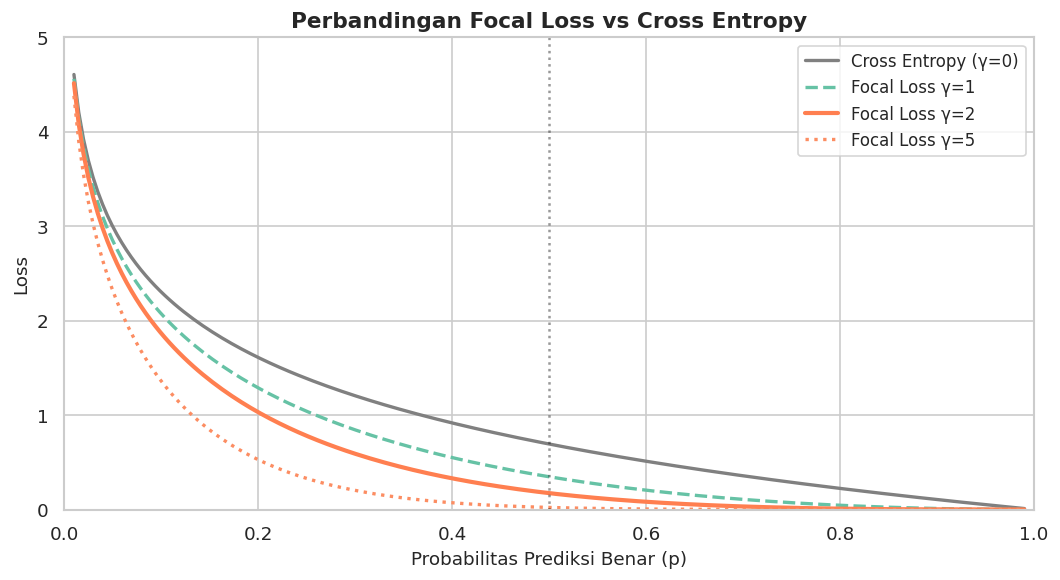

   Plot perbandingan loss disimpan: plot_focal_loss_comparison.png

   Insight dari plot:
   Saat p tinggi (prediksi mudah) → Focal Loss jauh lebih kecil dari CE
   Saat p rendah (prediksi susah) → Focal Loss ≈ CE, tetap beri penalti besar


In [ ]:
# Visualisasi perbedaan penalti Focal Loss vs Cross Entropy biasa

import matplotlib.pyplot as plt
import numpy as np

p = np.linspace(0.01, 0.99, 200)   # probabilitas prediksi benar

ce_loss    = -np.log(p)                        # Cross Entropy biasa
focal_loss_g1 = -(1 - p)**1 * np.log(p)       # Focal Loss gamma=1
focal_loss_g2 = -(1 - p)**2 * np.log(p)       # Focal Loss gamma=2
focal_loss_g5 = -(1 - p)**5 * np.log(p)       # Focal Loss gamma=5

plt.figure(figsize=(9, 5))
plt.plot(p, ce_loss,       label='Cross Entropy (γ=0)', linewidth=2, color='gray')
plt.plot(p, focal_loss_g1, label='Focal Loss γ=1',      linewidth=2, linestyle='--')
plt.plot(p, focal_loss_g2, label='Focal Loss γ=2 ',   linewidth=2.5, color='coral')
plt.plot(p, focal_loss_g5, label='Focal Loss γ=5',      linewidth=2, linestyle=':')

plt.xlabel('Probabilitas Prediksi Benar (p)', fontsize=11)
plt.ylabel('Loss', fontsize=11)
plt.title('Perbandingan Focal Loss vs Cross Entropy', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.ylim(0, 5)
plt.xlim(0, 1)
plt.axvline(x=0.5, color='black', linestyle=':', alpha=0.4, label='p=0.5')
plt.tight_layout()
plt.savefig('plot_focal_loss_comparison.png')
plt.show()

print("   Plot perbandingan loss disimpan: plot_focal_loss_comparison.png")
print()
print("   Insight dari plot:")
print("   Saat p tinggi (prediksi mudah) → Focal Loss jauh lebih kecil dari CE")
print("   Saat p rendah (prediksi susah) → Focal Loss ≈ CE, tetap beri penalti besar")

Compile Model dengan Focal Loss

In [ ]:
# Sekarang kita compile model menggunakan FocalLoss yang sudah dibuat

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=FocalLoss(gamma=2.0, alpha=0.25),    # ← CUSTOM LOSS
    metrics=['accuracy']
)

print("   Model berhasil di-compile dengan FocalLoss!")
print()
print("   Optimizer : Adam (lr=0.001)")
print("   Loss      : FocalLoss (gamma=2.0, alpha=0.25)  ← Custom ")
print("   Metrics   : Accuracy")
print()
print("   Step 2c selesai!")
print("   Selanjutnya: Step 2d — Custom Callback")


   Model berhasil di-compile dengan FocalLoss!

   Optimizer : Adam (lr=0.001)
   Loss      : FocalLoss (gamma=2.0, alpha=0.25)  ← Custom 
   Metrics   : Accuracy

   Step 2c selesai!
   Selanjutnya: Step 2d — Custom Callback


#BAGIAN 10 — Custom Callback (NutriTrackCallback)
 Callback adalah kode yang otomatis berjalan di setiap epoch
 selama proses training berlangsung.

Definisi Custom Callback

In [ ]:
import csv
import os
from datetime import datetime

class NutriTrackCallback(tf.keras.callbacks.Callback):
    def __init__(self, log_file='training_log.csv', patience=10, min_delta=0.001):
        super(NutriTrackCallback, self).__init__()

        self.log_file  = log_file    # file untuk simpan log training
        self.patience  = patience    # berapa epoch toleransi tidak ada peningkatan
        self.min_delta = min_delta   # peningkatan minimum yang dianggap signifikan

        # Variabel internal
        self.best_val_accuracy = 0.0
        self.wait              = 0       # hitung epoch tanpa peningkatan
        self.best_epoch        = 0
        self.stopped_epoch     = 0

    def on_train_begin(self, logs=None):
        # Jalan sekali di awal training
        print("   Training dimulai!")
        print(f"   Log disimpan ke   : {self.log_file}")
        print(f"   Patience          : {self.patience} epoch")
        print(f"   Min delta         : {self.min_delta}")
        print("-" * 55)

        # Buat file CSV dengan header
        with open(self.log_file, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['epoch', 'loss', 'accuracy',
                             'val_loss', 'val_accuracy',
                             'is_best', 'timestamp'])

    def on_epoch_end(self, epoch, logs=None):
        # Jalan di setiap akhir epoch
        logs = logs or {}

        loss         = logs.get('loss', 0)
        accuracy     = logs.get('accuracy', 0)
        val_loss     = logs.get('val_loss', 0)
        val_accuracy = logs.get('val_accuracy', 0)

        # Cek apakah ini epoch terbaik
        is_best = val_accuracy > (self.best_val_accuracy + self.min_delta)

        if is_best:
            self.best_val_accuracy = val_accuracy
            self.best_epoch        = epoch + 1
            self.wait              = 0

            # Simpan model terbaik
            self.model.save('nutritrack_best_model.keras')

            status = f"BEST! Val Acc: {val_accuracy:.4f} — model disimpan"
        else:
            self.wait += 1
            status = f"   Val Acc: {val_accuracy:.4f} — no improvement ({self.wait}/{self.patience})"

        # Print progress per epoch
        print(f"Epoch {epoch+1:>3} | "
              f"loss: {loss:.4f} | acc: {accuracy:.4f} | "
              f"val_loss: {val_loss:.4f} | {status}")

        # Catat ke CSV
        with open(self.log_file, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch + 1,
                round(loss, 4),
                round(accuracy, 4),
                round(val_loss, 4),
                round(val_accuracy, 4),
                is_best,
                datetime.now().strftime('%H:%M:%S')
            ])

        # Early stopping — hentikan jika patience habis
        if self.wait >= self.patience:
            self.stopped_epoch       = epoch + 1
            self.model.stop_training = True

    def on_train_end(self, logs=None):
        # Jalan sekali di akhir training
        print("-" * 55)
        if self.stopped_epoch > 0:
            print(f"Early stopping di epoch {self.stopped_epoch}")
        print(f"Model terbaik    : epoch {self.best_epoch}")
        print(f"Best val accuracy: {self.best_val_accuracy:.4f} "
              f"({self.best_val_accuracy*100:.2f}%)")
        print(f"📄 Log tersimpan di : {self.log_file}")


print("NutriTrackCallback berhasil didefinisikan!")

NutriTrackCallback berhasil didefinisikan!


Siapkan Semua Callback untuk Training

In [ ]:
# Kita pakai 2 callback:
# 1. NutriTrackCallback  → custom buatan kita
# 2. ReduceLROnPlateau   → kurangi learning rate otomatis jika stagnan

nutritrack_cb = NutriTrackCallback(
    log_file  = 'training_log.csv',
    patience  = 10,
    min_delta = 0.001
)

reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,        # learning rate dikali 0.5 jika stagnan
    patience = 5,          # tunggu 5 epoch sebelum kurangi lr
    min_lr   = 1e-6,
    verbose  = 0           # silent, sudah ada log di NutriTrackCallback
)

callbacks_list = [nutritrack_cb, reduce_lr_cb]

print("   Callbacks siap digunakan!")
print()
print("   [1] NutriTrackCallback  → log CSV + auto-save + early stopping ")
print("   [2] ReduceLROnPlateau   → auto-kurangi learning rate jika stagnan")
print()
print("   Step 2d selesai!")
print("   Selanjutnya: Step 2e — Training Model!")

   Callbacks siap digunakan!

   [1] NutriTrackCallback  → log CSV + auto-save + early stopping 
   [2] ReduceLROnPlateau   → auto-kurangi learning rate jika stagnan

   Step 2d selesai!
   Selanjutnya: Step 2e — Training Model!


#BAGIAN 11 — Training Model
 Sekarang kita latih model menggunakan semua komponen
 yang sudah dibuat di step sebelumnya.

Konversi Label ke One-Hot (untuk Focal Loss)

In [ ]:
# Focal Loss kita butuh y dalam bentuk integer (bukan one-hot)
# Tapi kita pastikan tipe datanya benar

y_train_int = y_train.astype('int32')
y_val_int   = y_val.astype('int32')
y_test_int  = y_test.astype('int32')

print("   Label siap untuk training!")
print(f"   y_train shape : {y_train_int.shape}, dtype: {y_train_int.dtype}")
print(f"   y_val shape   : {y_val_int.shape},   dtype: {y_val_int.dtype}")
print(f"   y_test shape  : {y_test_int.shape},  dtype: {y_test_int.dtype}")
print()

# Cek distribusi kelas di train set
unique, counts = np.unique(y_train_int, return_counts=True)
target_names = [
    'Insufficient_Weight', 'Normal_Weight',
    'Overweight_Level_I',  'Overweight_Level_II',
    'Obesity_Type_I',      'Obesity_Type_II', 'Obesity_Type_III'
]
print("Distribusi kelas di Training Set:")
for u, c in zip(unique, counts):
    print(f"   {target_names[u]:<25}: {c} sampel")

   Label siap untuk training!
   y_train shape : (1460,), dtype: int32
   y_val shape   : (313,),   dtype: int32
   y_test shape  : (314,),  dtype: int32

Distribusi kelas di Training Set:
   Insufficient_Weight      : 187 sampel
   Normal_Weight            : 197 sampel
   Overweight_Level_I       : 193 sampel
   Overweight_Level_II      : 203 sampel
   Obesity_Type_I           : 245 sampel
   Obesity_Type_II          : 208 sampel
   Obesity_Type_III         : 227 sampel


Mulai Training

In [ ]:
print("Memulai training...\n")

history = model.fit(
    X_train, y_train_int,
    epochs          = 100,
    batch_size      = 32,
    validation_data = (X_val, y_val_int),
    callbacks       = callbacks_list,   # NutriTrackCallback + ReduceLROnPlateau
    verbose         = 0                 # silent — output dihandle NutriTrackCallback
)

Memulai training...

   Training dimulai!
   Log disimpan ke   : training_log.csv
   Patience          : 10 epoch
   Min delta         : 0.001
-------------------------------------------------------
Epoch   1 | loss: 0.3457 | acc: 0.3103 | val_loss: 0.3513 | BEST! Val Acc: 0.2620 — model disimpan
Epoch   2 | loss: 0.2735 | acc: 0.4301 | val_loss: 0.3325 | BEST! Val Acc: 0.3642 — model disimpan
Epoch   3 | loss: 0.2078 | acc: 0.5027 | val_loss: 0.2821 | BEST! Val Acc: 0.4026 — model disimpan
Epoch   4 | loss: 0.1647 | acc: 0.5336 | val_loss: 0.2160 |    Val Acc: 0.4026 — no improvement (1/10)
Epoch   5 | loss: 0.1458 | acc: 0.5705 | val_loss: 0.1776 | BEST! Val Acc: 0.4856 — model disimpan
Epoch   6 | loss: 0.1281 | acc: 0.6171 | val_loss: 0.1754 |    Val Acc: 0.4728 — no improvement (1/10)
Epoch   7 | loss: 0.1192 | acc: 0.6260 | val_loss: 0.1351 | BEST! Val Acc: 0.5879 — model disimpan
Epoch   8 | loss: 0.1034 | acc: 0.6616 | val_loss: 0.1144 | BEST! Val Acc: 0.6518 — model disimpan
E

Ringkasan Hasil Training

In [ ]:
import pandas as pd

# Baca log CSV yang dibuat callback
log_df = pd.read_csv('training_log.csv')

print("   Ringkasan Training:")
print(f"   Total epoch berjalan : {len(log_df)}")
print(f"   Best epoch           : {log_df.loc[log_df['val_accuracy'].idxmax(), 'epoch']}")
print(f"   Best val accuracy    : {log_df['val_accuracy'].max():.4f} ({log_df['val_accuracy'].max()*100:.2f}%)")
print(f"   Best val loss        : {log_df['val_loss'].min():.4f}")
print()
print("5 Epoch Terbaik berdasarkan Val Accuracy:")
print(log_df.nlargest(5, 'val_accuracy')[
    ['epoch', 'accuracy', 'val_accuracy', 'val_loss', 'is_best']
].to_string(index=False))

   Ringkasan Training:
   Total epoch berjalan : 50
   Best epoch           : 40
   Best val accuracy    : 0.9073 (90.73%)
   Best val loss        : 0.0353

5 Epoch Terbaik berdasarkan Val Accuracy:
 epoch  accuracy  val_accuracy  val_loss  is_best
    40    0.8192        0.9073    0.0429     True
    47    0.8363        0.8914    0.0398    False
    48    0.8514        0.8914    0.0397    False
    46    0.8432        0.8818    0.0393    False
    39    0.8521        0.8754    0.0417     True


Plot Kurva Training

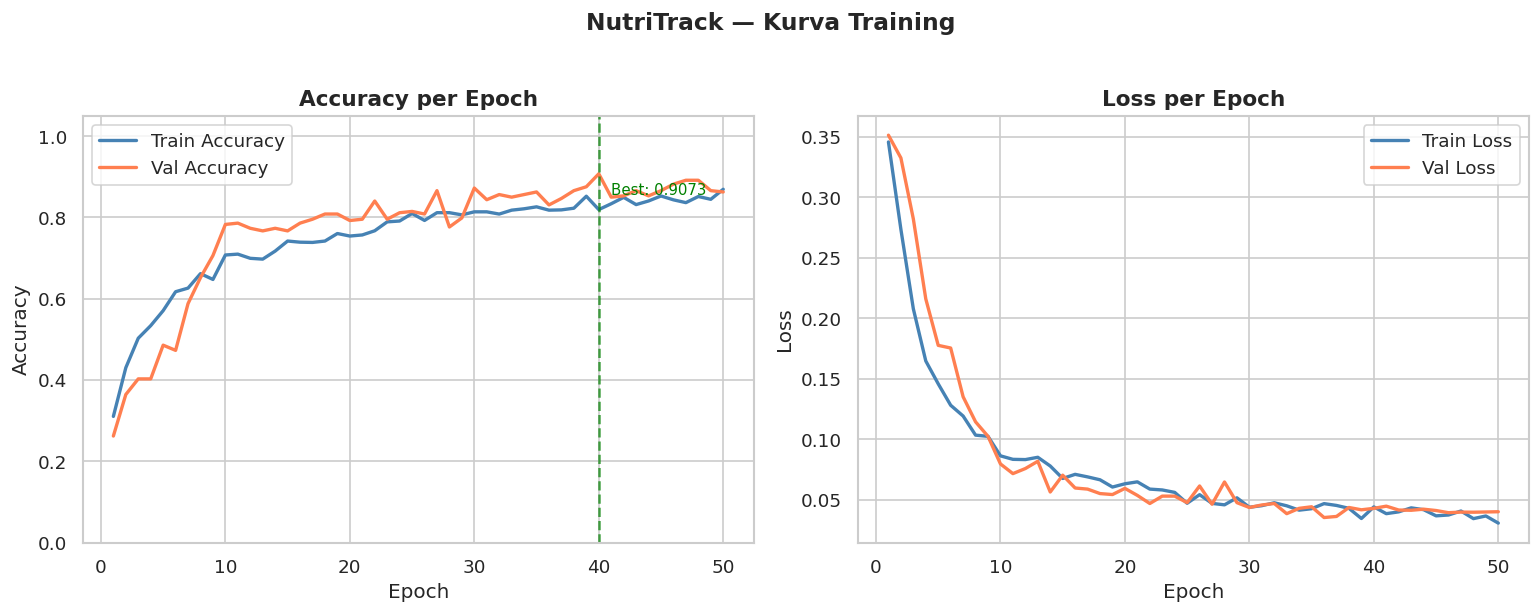

Plot kurva training disimpan: plot_training_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot Accuracy ---
axes[0].plot(log_df['epoch'], log_df['accuracy'],
             label='Train Accuracy', color='steelblue', linewidth=2)
axes[0].plot(log_df['epoch'], log_df['val_accuracy'],
             label='Val Accuracy', color='coral', linewidth=2)

# Tandai best epoch
best_epoch = log_df.loc[log_df['val_accuracy'].idxmax(), 'epoch']
best_val   = log_df['val_accuracy'].max()
axes[0].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7)
axes[0].annotate(f'Best: {best_val:.4f}',
                 xy=(best_epoch, best_val),
                 xytext=(best_epoch + 1, best_val - 0.05),
                 fontsize=9, color='green')

axes[0].set_title('Accuracy per Epoch', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_ylim(0, 1.05)

# --- Plot Loss ---
axes[1].plot(log_df['epoch'], log_df['loss'],
             label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(log_df['epoch'], log_df['val_loss'],
             label='Val Loss', color='coral', linewidth=2)
axes[1].set_title('Loss per Epoch', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('NutriTrack — Kurva Training', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_training_curves.png')
plt.show()

print("Plot kurva training disimpan: plot_training_curves.png")

Cek Apakah Target Akurasi Tercapai

In [ ]:
TARGET_ACCURACY = 0.85  # syarat minimum dari worksheet

best_val_acc = log_df['val_accuracy'].max()

print("   Pengecekan Target Akurasi:")
print(f"   Target minimum  : {TARGET_ACCURACY*100:.0f}%")
print(f"   Val accuracy    : {best_val_acc*100:.2f}%")
print()

if best_val_acc >= TARGET_ACCURACY:
    print(f"TARGET TERCAPAI! ({best_val_acc*100:.2f}% ≥ 85%)")
else:
    gap = (TARGET_ACCURACY - best_val_acc) * 100
    print(f"    Belum tercapai, kurang {gap:.2f}%")
    print("   Tips: coba tambah epoch, turunkan dropout, atau naikkan batch size")

print()
print("   Step 2e selesai!")
print("   Selanjutnya: Step 2f — Evaluasi & Confusion Matrix")

   Pengecekan Target Akurasi:
   Target minimum  : 85%
   Val accuracy    : 90.73%

TARGET TERCAPAI! (90.73% ≥ 85%)

   Step 2e selesai!
   Selanjutnya: Step 2f — Evaluasi & Confusion Matrix


# BAGIAN 12 — Evaluasi Model
Kita evaluasi model menggunakan data test yang belum pernahdilihat model selama training.

Load Model Terbaik & Evaluasi di Test Set

In [ ]:
from tensorflow.keras.models import load_model

# Load model terbaik yang disimpan oleh NutriTrackCallback
best_model = load_model(
    'nutritrack_best_model.keras',
    custom_objects={
        'AttentionLayer': AttentionLayer,
        'FocalLoss'     : FocalLoss
    }
)

# Evaluasi di test set
test_loss, test_accuracy = best_model.evaluate(
    X_test, y_test_int, verbose=0
)

print("   Hasil Evaluasi di Test Set:")
print(f"   Test Loss     : {test_loss:.4f}")
print(f"   Test Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print()

if test_accuracy >= 0.85:
    print("Target akurasi 85% TERCAPAI!")
else:
    print(f"Akurasi {test_accuracy*100:.2f}% — belum mencapai target 85%")

   Hasil Evaluasi di Test Set:
   Test Loss     : 0.0308
   Test Accuracy : 0.9331 (93.31%)

Target akurasi 85% TERCAPAI!


Classification Report (Precision, Recall, F1)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

target_names = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

# Prediksi di test set
y_pred_proba = best_model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

print("Classification Report:")
print("=" * 65)
print(classification_report(y_test_int, y_pred,
                             target_names=target_names,
                             digits=4))

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight     0.8163    1.0000    0.8989        40
      Normal_Weight     0.9412    0.7619    0.8421        42
 Overweight_Level_I     0.9070    0.9512    0.9286        41
Overweight_Level_II     0.9535    0.9318    0.9425        44
     Obesity_Type_I     0.9608    0.9245    0.9423        53
    Obesity_Type_II     0.9565    0.9778    0.9670        45
   Obesity_Type_III     1.0000    0.9796    0.9897        49

           accuracy                         0.9331       314
          macro avg     0.9336    0.9324    0.9302       314
       weighted avg     0.9372    0.9331    0.9325       314



Confusion Matrix

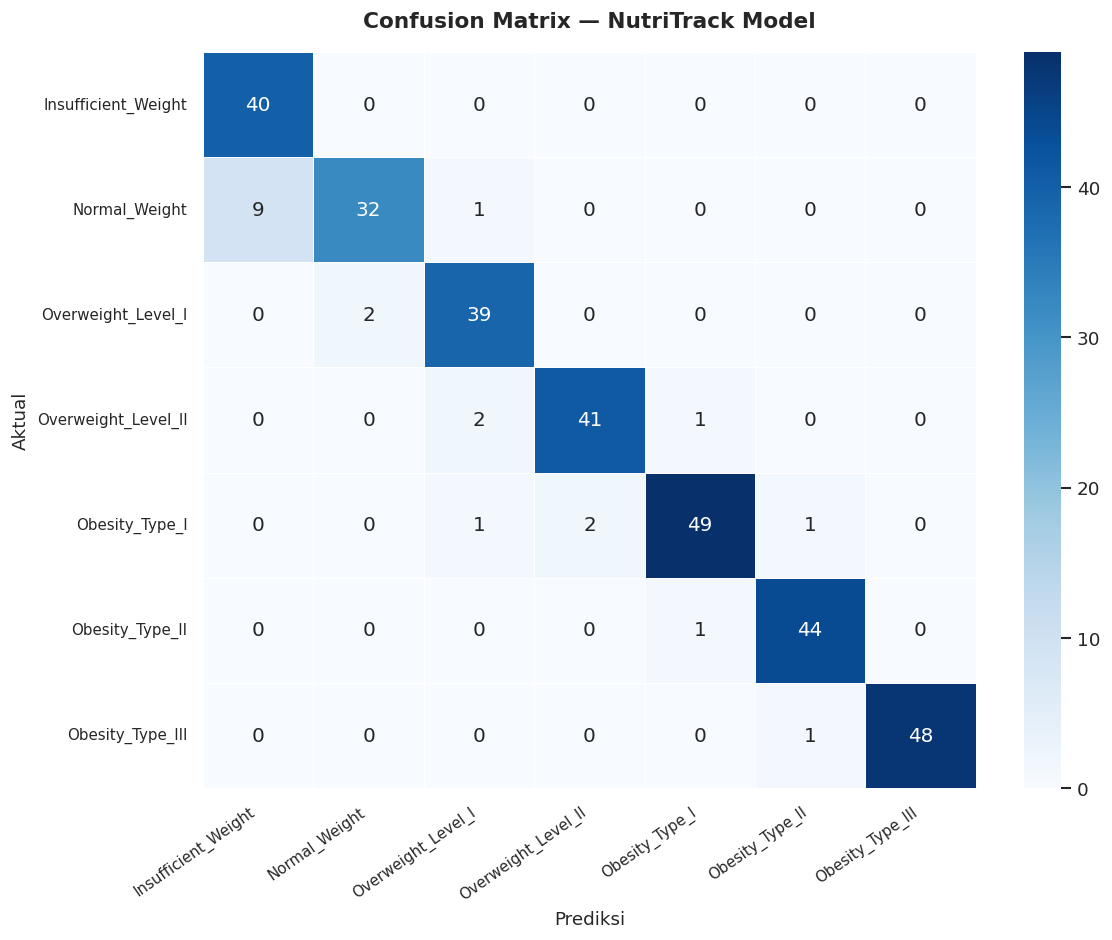

Confusion matrix disimpan: plot_confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_test_int, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    ax=ax,
    linewidths=0.5
)
ax.set_title('Confusion Matrix — NutriTrack Model',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Prediksi', fontsize=11)
ax.set_ylabel('Aktual', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('plot_confusion_matrix.png')
plt.show()

print("Confusion matrix disimpan: plot_confusion_matrix.png")

Akurasi Per Kelas

In [ ]:
print("Akurasi Per Kelas:")
print("-" * 45)
for i, name in enumerate(target_names):
    total_actual = cm[i].sum()
    correct      = cm[i][i]
    acc          = correct / total_actual * 100
    bar          = "█" * int(acc / 5)
    print(f"   {name:<25}: {acc:5.1f}% {bar}")

Akurasi Per Kelas:
---------------------------------------------
   Insufficient_Weight      : 100.0% ████████████████████
   Normal_Weight            :  76.2% ███████████████
   Overweight_Level_I       :  95.1% ███████████████████
   Overweight_Level_II      :  93.2% ██████████████████
   Obesity_Type_I           :  92.5% ██████████████████
   Obesity_Type_II          :  97.8% ███████████████████
   Obesity_Type_III         :  98.0% ███████████████████


Simpan Model dalam Format SavedModel

In [ ]:
# Simpan dalam 2 format sesuai syarat worksheet:
# 1. .keras  → format baru TensorFlow
# 2. SavedModel → format produksi

import os

# Format .keras (sudah tersimpan otomatis oleh callback)
print("Format .keras sudah tersimpan: nutritrack_best_model.keras")

# Format SavedModel u
os.makedirs('nutritrack_savedmodel', exist_ok=True)
best_model.export('nutritrack_savedmodel')
print("Format SavedModel tersimpan: nutritrack_savedmodel/")

print()
print("   File model yang tersimpan:")
print("   nutritrack_best_model.keras  ← format .keras")
print("   nutritrack_savedmodel/       ← format SavedModel (produksi)")

Format .keras sudah tersimpan: nutritrack_best_model.keras
Saved artifact at 'nutritrack_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 16), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  133203303695760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133203303694416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133203303695952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133203303697104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133203303697488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133203303698256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133203303700176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133203303697296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133203303699024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133203303709392: TensorSpec(sh

Kode Inference + Rekomendasi

In [ ]:
REKOMENDASI = {
    'Insufficient_Weight': {
        'status'    : '⚠️ Berat Badan Kurang',
        'deskripsi' : 'Berat badanmu berada di bawah batas normal. Tubuh membutuhkan lebih banyak nutrisi.',
        'diet'      : [
            'Tambah asupan kalori 300–500 kkal/hari dari sumber sehat',
            'Perbanyak konsumsi protein: telur, ayam, ikan, kacang-kacangan',
            'Konsumsi karbohidrat kompleks: nasi merah, oat, ubi',
            'Makan 5–6 kali sehari dalam porsi lebih kecil tapi sering',
            'Tambahkan lemak sehat: alpukat, kacang almond, minyak zaitun',
        ],
        'olahraga'  : [
            'Fokus ke latihan kekuatan (strength training) 3x seminggu',
            'Hindari kardio berlebihan yang membakar terlalu banyak kalori',
            'Yoga atau pilates untuk meningkatkan massa otot ringan',
        ],
        'medis'     : [
            'Konsultasi ke dokter gizi untuk program penambahan berat badan',
            'Cek kemungkinan gangguan tiroid atau masalah pencernaan',
            'Pertimbangkan suplemen jika direkomendasikan dokter',
        ]
    },
    'Normal_Weight': {
        'status'    : '✅ Berat Badan Normal',
        'deskripsi' : 'Selamat! Berat badanmu berada di rentang ideal. Pertahankan gaya hidup sehatmu.',
        'diet'      : [
            'Pertahankan pola makan seimbang dengan gizi lengkap',
            'Konsumsi sayur dan buah minimal 5 porsi per hari',
            'Batasi makanan tinggi gula dan lemak jenuh',
            'Minum air putih minimal 8 gelas per hari',
            'Jangan skip sarapan untuk menjaga metabolisme',
        ],
        'olahraga'  : [
            'Olahraga rutin 3–4x seminggu minimal 30 menit',
            'Kombinasikan kardio (lari, renang) dan latihan kekuatan',
            'Tetap aktif bergerak di sela-sela aktivitas harian',
        ],
        'medis'     : [
            'Lakukan medical check-up rutin setahun sekali',
            'Pantau berat badan secara berkala setiap bulan',
        ]
    },
    'Overweight_Level_I': {
        'status'    : '⚠️ Kelebihan Berat Badan Tingkat I',
        'deskripsi' : 'Berat badanmu sedikit di atas normal. Ini saat yang tepat untuk mulai perubahan gaya hidup.',
        'diet'      : [
            'Kurangi asupan kalori 300–500 kkal/hari secara bertahap',
            'Hindari makanan tinggi gula: minuman manis, kue, permen',
            'Perbanyak sayuran dan protein tanpa lemak',
            'Hindari makan larut malam (setelah pukul 20.00)',
            'Gunakan piring lebih kecil untuk kontrol porsi',
        ],
        'olahraga'  : [
            'Mulai dengan jalan kaki 30 menit setiap hari',
            'Tingkatkan intensitas secara bertahap ke jogging ringan',
            'Olahraga minimal 4x seminggu',
            'Kurangi waktu duduk/screen time yang berlebihan',
        ],
        'medis'     : [
            'Konsultasi ke dokter atau ahli gizi untuk program diet',
            'Pantau tekanan darah dan kadar gula darah secara rutin',
        ]
    },
    'Overweight_Level_II': {
        'status'    : '⚠️ Kelebihan Berat Badan Tingkat II',
        'deskripsi' : 'Berat badanmu cukup jauh di atas normal. Perubahan gaya hidup serius sangat dianjurkan.',
        'diet'      : [
            'Kurangi asupan kalori 500–750 kkal/hari dengan panduan ahli gizi',
            'Hindari semua makanan ultra-processed dan fast food',
            'Konsumsi makanan tinggi serat: sayur, buah, biji-bijian',
            'Batasi karbohidrat sederhana, pilih karbohidrat kompleks',
            'Catat asupan makanan harian (food journal)',
        ],
        'olahraga'  : [
            'Olahraga 5x seminggu minimal 45 menit per sesi',
            'Kombinasi kardio intensitas sedang dan latihan beban',
            'Pertimbangkan kelas olahraga terpandu (zumba, aerobik)',
            'Target penurunan berat badan 0.5–1 kg per minggu',
        ],
        'medis'     : [
            'Wajib konsultasi ke dokter dan ahli gizi',
            'Cek kadar kolesterol, gula darah, dan tekanan darah',
            'Evaluasi kesehatan secara menyeluruh sebelum memulai program',
        ]
    },
    'Obesity_Type_I': {
        'status'    : '🔴 Obesitas Tipe I',
        'deskripsi' : 'Kamu mengalami obesitas tingkat pertama. Penanganan segera sangat dianjurkan untuk mencegah komplikasi.',
        'diet'      : [
            'Ikuti program diet terstruktur dengan panduan ahli gizi',
            'Kurangi kalori secara signifikan namun tetap penuhi kebutuhan nutrisi',
            'Hindari total: minuman manis, gorengan, fast food',
            'Perbanyak protein untuk menjaga massa otot saat diet',
            'Makan dengan perlahan dan mindful eating',
        ],
        'olahraga'  : [
            'Olahraga minimal 5x seminggu, 60 menit per sesi',
            'Mulai dengan olahraga low-impact: renang, bersepeda, jalan cepat',
            'Hindari olahraga berintensitas tinggi tanpa supervisi',
            'Tingkatkan aktivitas fisik harian: naik tangga, jalan kaki',
        ],
        'medis'     : [
            'WAJIB konsultasi dokter sebelum memulai program apapun',
            'Periksa risiko diabetes tipe 2, hipertensi, dan penyakit jantung',
            'Pertimbangkan program penurunan berat badan medis terstruktur',
            'Evaluasi kesehatan mental — stres bisa memperburuk obesitas',
        ]
    },
    'Obesity_Type_II': {
        'status'    : '🔴 Obesitas Tipe II',
        'deskripsi' : 'Kamu mengalami obesitas tingkat dua. Kondisi ini membutuhkan penanganan medis yang serius.',
        'diet'      : [
            'Diet harus dalam pengawasan ketat dokter dan ahli gizi',
            'Program diet rendah kalori sangat rendah (VLCD) jika direkomendasikan',
            'Fokus pada makanan anti-inflamasi: ikan, sayur hijau, berry',
            'Hindari total alkohol dan minuman manis',
            'Pertimbangkan meal replacement yang direkomendasikan dokter',
        ],
        'olahraga'  : [
            'Olahraga HANYA dengan supervisi profesional',
            'Mulai sangat perlahan: jalan kaki 15–20 menit, tingkatkan bertahap',
            'Renang sangat dianjurkan karena minim tekanan pada sendi',
            'Fisioterapi mungkin diperlukan jika ada masalah sendi',
        ],
        'medis'     : [
            'SEGERA konsultasi dokter spesialis gizi atau endokrinologi',
            'Evaluasi komplikasi: sleep apnea, diabetes, hipertensi, GERD',
            'Diskusikan kemungkinan terapi medis atau bedah bariatrik',
            'Dukungan psikologis sangat dianjurkan',
            'Pantau kondisi kesehatan setiap 1–3 bulan',
        ]
    },
    'Obesity_Type_III': {
        'status'    : '🚨 Obesitas Tipe III (Obesitas Morbid)',
        'deskripsi' : 'Ini adalah tingkat obesitas paling berat. Intervensi medis segera sangat diperlukan.',
        'diet'      : [
            'Diet HARUS di bawah pengawasan ketat tim medis',
            'Kemungkinan memerlukan diet cair atau VLCD di bawah supervisi',
            'Suplemen vitamin dan mineral wajib karena risiko defisiensi',
            'Tidak dianjurkan melakukan diet sendiri tanpa panduan dokter',
        ],
        'olahraga'  : [
            'Aktivitas fisik HANYA atas rekomendasi dan supervisi dokter',
            'Terapi fisik/fisioterapi sebagai langkah awal',
            'Olahraga dalam air (hidroterapi) bisa menjadi pilihan aman',
        ],
        'medis'     : [
            'SEGERA temui dokter spesialis — ini kondisi darurat kesehatan',
            'Evaluasi menyeluruh: jantung, paru, diabetes, kolesterol',
            'Operasi bariatrik (sleeve gastrectomy/bypass lambung) perlu didiskusikan',
            'Dukungan psikiatri/psikologi sangat penting',
            'Pemantauan medis intensif setiap bulan',
            'Libatkan keluarga dalam proses pemulihan',
        ]
    }
}


# --- Fungsi Prediksi + Rekomendasi ---
def predict_obesity_with_recommendation(data_input, model):
    target_names = [
        'Insufficient_Weight', 'Normal_Weight',
        'Overweight_Level_I',  'Overweight_Level_II',
        'Obesity_Type_I',      'Obesity_Type_II', 'Obesity_Type_III'
    ]

    input_array  = np.array(data_input).reshape(1, -1)
    proba        = model.predict(input_array, verbose=0)[0]
    pred_class   = np.argmax(proba)
    pred_name    = target_names[pred_class]
    rekomendasi  = REKOMENDASI[pred_name]

    return {
        'predicted_class'      : pred_name,
        'predicted_class_index': int(pred_class),
        'confidence'           : float(proba[pred_class]),
        'status'               : rekomendasi['status'],
        'deskripsi'            : rekomendasi['deskripsi'],
        'rekomendasi_diet'     : rekomendasi['diet'],
        'rekomendasi_olahraga' : rekomendasi['olahraga'],
        'rekomendasi_medis'    : rekomendasi['medis'],
        'all_probabilities'    : {
            name: float(p) for name, p in zip(target_names, proba)
        }
    }


# --- Contoh Penggunaan ---
sample_input = X_test[100]
result = predict_obesity_with_recommendation(sample_input, best_model)

print("=" * 55)
print("🔍 HASIL PREDIKSI NUTRITRACK")
print("=" * 55)
print(f"Kelas           : {result['predicted_class']}")
print(f"Status          : {result['status']}")
print(f"Confidence      : {result['confidence']*100:.2f}%")
print(f"Aktual          : {target_names[y_test_int[0]]}")
print()
print(f"📝 {result['deskripsi']}")
print()
print("🥗 Rekomendasi Diet:")
for r in result['rekomendasi_diet']:
    print(f"   • {r}")
print()
print("🏃 Rekomendasi Olahraga:")
for r in result['rekomendasi_olahraga']:
    print(f"   • {r}")
print()
print("🏥 Rekomendasi Medis:")
for r in result['rekomendasi_medis']:
    print(f"   • {r}")
print()
print("=" * 55)

print("   Selanjutnya Dashboard Streamlit")
print("=" * 55)

🔍 HASIL PREDIKSI NUTRITRACK
Kelas           : Obesity_Type_III
Status          : 🚨 Obesitas Tipe III (Obesitas Morbid)
Confidence      : 94.22%
Aktual          : Insufficient_Weight

📝 Ini adalah tingkat obesitas paling berat. Intervensi medis segera sangat diperlukan.

🥗 Rekomendasi Diet:
   • Diet HARUS di bawah pengawasan ketat tim medis
   • Kemungkinan memerlukan diet cair atau VLCD di bawah supervisi
   • Suplemen vitamin dan mineral wajib karena risiko defisiensi
   • Tidak dianjurkan melakukan diet sendiri tanpa panduan dokter

🏃 Rekomendasi Olahraga:
   • Aktivitas fisik HANYA atas rekomendasi dan supervisi dokter
   • Terapi fisik/fisioterapi sebagai langkah awal
   • Olahraga dalam air (hidroterapi) bisa menjadi pilihan aman

🏥 Rekomendasi Medis:
   • SEGERA temui dokter spesialis — ini kondisi darurat kesehatan
   • Evaluasi menyeluruh: jantung, paru, diabetes, kolesterol
   • Operasi bariatrik (sleeve gastrectomy/bypass lambung) perlu didiskusikan
   • Dukungan psikiatri/p

In [ ]:
from google.colab import files

files.download('nutritrack_best_model.keras')
files.download('dataset_cleaned.csv')
files.download('X_test.npy')
files.download('y_test.npy')
files.download('training_log.csv')
files.download('ObesityDataSet_raw_and_data_sinthetic__1_.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>